In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp
from jax import vmap, random

from myutils_2233 import Ntime, ACFs, simulate_one_par_full_jit, simulate_data_full_jit, set_detectors, load_tables
from myutils_2233 import ln_likelihood_full_jit, ln_likelihood_full
from myutils_2233 import patterns_for_params

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data #, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) #double precision

/Users/kallol/Work/Misc/skyRing_bak/examples/simulations_hm/../../src/myutils_2233.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Injection parameters
factor     = 10
N          = 1
seed       = 31567 
T          = 0.1 + 0.2
srate      = 4096 
t0         = 0.0
fmin       = 8
fmax       = 1500
components = 70
M_obs      = 300 
chi_obs    = 0.8 
A220_obs   = 0.7
P220_obs   = 4.1 
A330_obs   = 0.17 
P330_obs   = 1.5 
ra         = 3.5
dec        = 0.73
psi        = 1.329
iota       = 1.3 


tgps       = 1420888141.2379541 


psdH_path  = "../../data/PSDs/PSD_H1_GW250114.txt"
psdL_path  = "../../data/PSDs/PSD_L1_GW250114.txt"
qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"


In [4]:
delays = {}
tgps_calc = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_calc)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_calc = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_calc)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

In [5]:
tH1, tL1

(1420888141.219169, 1420888141.2173247)

In [8]:
# Precompute frequency grid and static slice indices on the host
dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

In [9]:
psdH, psdL, omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(psdH_path, psdL_path, qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

In [10]:
## simulate ringdown signal
seed = int(seed) if seed is not None else  (time.time_ns() ^ int.from_bytes(os.urandom(4), "little")) & 0xFFFFFFFF
# seed = (time.time_ns() ^ int.from_bytes(os.urandom(4), "little")) & 0xFFFFFFFF
master = random.PRNGKey(int(seed)) 
row_keys = random.split(master, int(N)+1) #one key is needed to simulate the observation

theta_GT = onp.array([M_obs, chi_obs, A220_obs, P220_obs, A330_obs, P330_obs, onp.cos(iota), ra, onp.cos(dec), psi], dtype=onp.float64) 

H_GT, _, h_H, h_L, h_H_t, h_L_t  = simulate_data_full_jit(
        params=theta_GT, 
        gmst=gmst, psdH=psdH, psdL=psdL, L_H=L_H, L_L=L_L,
        omega_22_r=omega_22_r, omega_22_i=omega_22_i, omega_33_r=omega_33_r, omega_33_i=omega_33_i,
        key=row_keys[-1], T=T, srate=srate, t0=t0, i0=i0, i1=i1, freqs=freqs, fmin=fmin, components=components, factor=factor
        )

In [11]:
dt = jnp.asarray(1.0/srate, dtype=jnp.float64)
Nlen = Ntime(srate=srate, T=T)
times  = jnp.arange(Nlen, dtype=jnp.float64) * dt

tH1_array = times + jnp.float64(tH1)
tL1_array = times + jnp.float64(tL1)

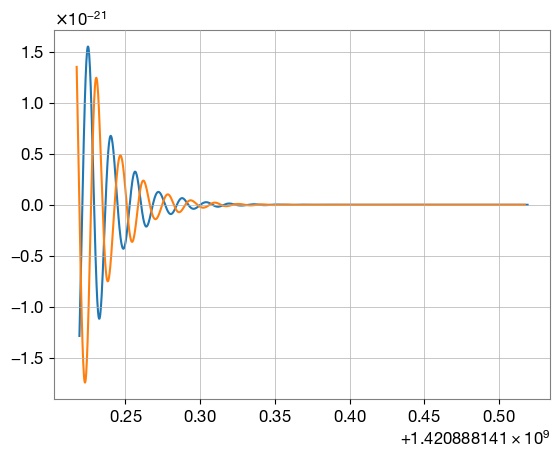

In [12]:
plt.plot(tH1_array, h_H_t)
plt.plot(tL1_array, h_L_t)
# plt.xlim(tH1, tH1+0.1)
plt.show()

In [ ]:
analysis_T = 0.2
n_analyze  = Ntime(srate=srate, T=analysis_T)

H1idx_start = onp.argwhere(tH1_array>=tH1)[0][0]
L1idx_start = onp.argwhere(tL1_array>=tH1)[0][0]

H1_analysis_data_new = analysis_data(h_H_t, tH1_array, tH1, n_analyze)
L1_analysis_data_new = analysis_data(h_L_t, tL1_array, tH1, n_analyze)

H1_analysis_data_old = analysis_data(h_H_t, tH1_array, tH1, n_analyze)
L1_analysis_data_old = analysis_data(h_L_t, tL1_array, tL1, n_analyze)

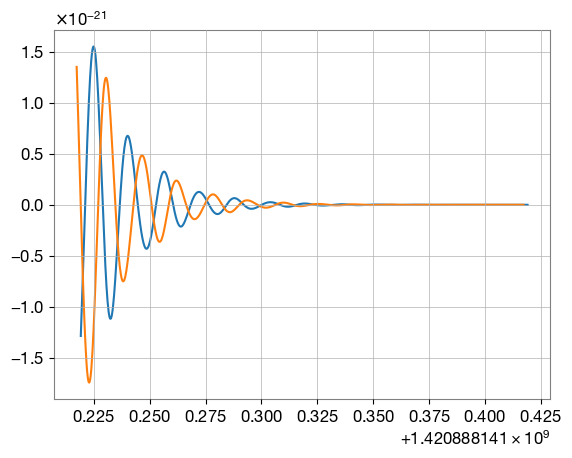

In [14]:
plt.plot(H1_analysis_data_old[0], H1_analysis_data_old[1])
plt.plot(L1_analysis_data_old[0], L1_analysis_data_old[1])
plt.show()

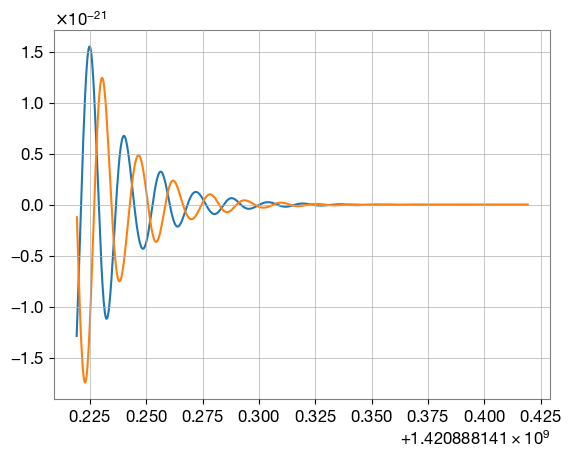

In [15]:
plt.plot(H1_analysis_data_new[0], H1_analysis_data_new[1])
plt.plot(L1_analysis_data_new[0], L1_analysis_data_new[1])
plt.show()

In [ ]:
onp.savetxt('./H1-sim-new.txt', H1_analysis_data_new[1])
onp.savetxt('./L1-sim-new.txt', L1_analysis_data_new[1])

onp.savetxt('./H1-sim-old.txt', H1_analysis_data_old[1])
onp.savetxt('./L1-sim-old.txt', L1_analysis_data_old[1])